In [1]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [2]:
# define the dl model
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

# useful function to compute derivatives of the solution
def derivatives(u, x, t):
    u_t = torch.autograd.grad(u, t, 
                              grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]

    u_tt = torch.autograd.grad(u_t, t,
                               grad_outputs=torch.ones_like(u_t),
                               create_graph=True)[0]

    u_x = torch.autograd.grad(u, x,
                              grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x,
                               grad_outputs=torch.ones_like(u_x),
                               create_graph=True)[0]

    return u_tt, u_xx, u_t

In [3]:
# define the phyisical loss funcion that impose the edp
def physics_loss(model, x, t, c):
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)
    u_tt, u_xx, _ = derivatives(u, x, t)

    residual = u_tt - c**2 * u_xx
    return torch.mean(residual**2)

# define the initial condution as another term of the loss function
def initial_loss(model, x, c, L):
    t0 = torch.zeros_like(x)

    x.requires_grad_(True)
    t0.requires_grad_(True)

    u = model(x, t0)
    u_tt, u_xx, u_t = derivatives(u, x, t0)

    u0 = torch.sin(np.pi * x / L)

    loss_u0 = torch.mean((u - u0)**2)
    loss_ut0 = torch.mean(u_t**2)

    return loss_u0 + loss_ut0

# another term of the loss function to include boundary conditions
def boundary_loss(model, t, L):
    x0 = torch.zeros_like(t)
    xL = torch.ones_like(t) * L

    u0 = model(x0, t)
    uL = model(xL, t)

    return torch.mean(u0**2) + torch.mean(uL**2)

In [4]:
# solve the problem by training the network
device = "cpu"
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=2000)
L = 1.0
T = 1.0
c = 1.0

for epoch in tqdm(range(5000), desc="solving"):

    # collocation points
    x_f = torch.rand(1000,1).to(device)*L
    t_f = torch.rand(1000,1).to(device)*T

    # initial
    x_i = torch.rand(200,1).to(device)*L

    # boundary
    t_b = torch.rand(200,1).to(device)*T

    loss_f = physics_loss(model, x_f, t_f, c)
    loss_i = initial_loss(model, x_i, c, L)
    loss_b = boundary_loss(model, t_b, L)

    loss = loss_f + loss_i + loss_b

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

solving: 100%|██████████| 5000/5000 [01:43<00:00, 48.15it/s]


In [5]:
# compare with the analytical solution
def exact_solution(x, t):
    return torch.sin(np.pi*x/L)*torch.cos(np.pi*c*t/L)

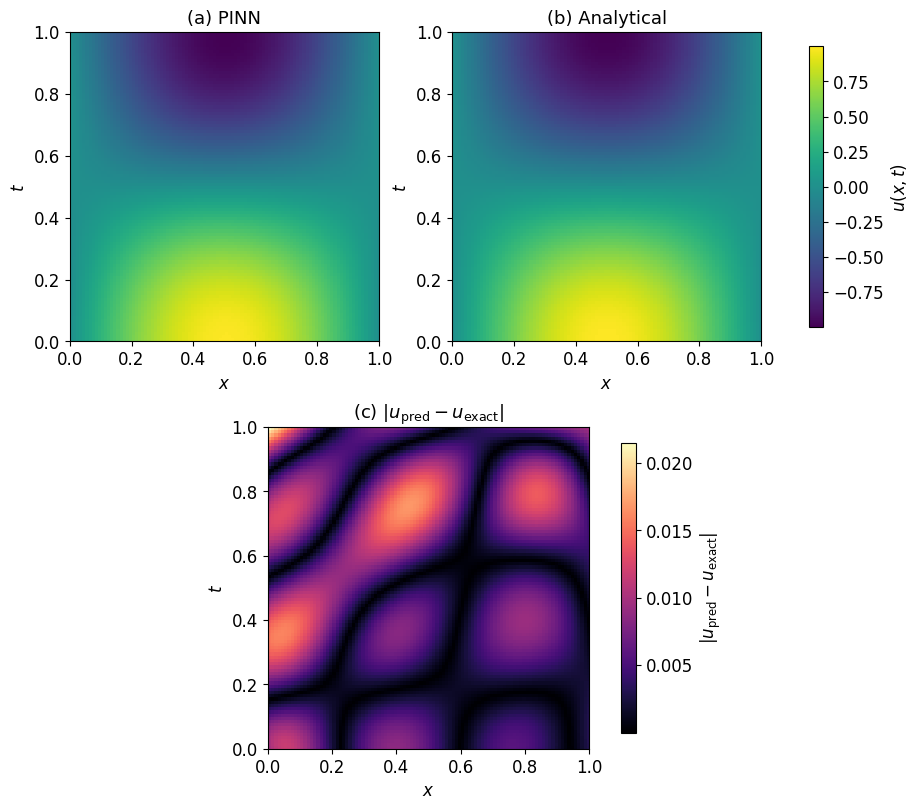

In [6]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

# ----- Grid -----
Nx, Nt = 100, 100
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)
X, T_grid = np.meshgrid(x, t)

x_tensor = torch.tensor(X.reshape(-1,1), dtype=torch.float32).to(device)
t_tensor = torch.tensor(T_grid.reshape(-1,1), dtype=torch.float32).to(device)

# ----- PINN prediction -----
model.eval()
with torch.no_grad():
    U_pred = model(x_tensor, t_tensor).cpu().numpy().reshape(Nt, Nx)

# ----- Analytical solution -----
def exact_solution(x, t):
    return torch.sin(np.pi*x/L) * torch.cos(np.pi*c*t/L)

U_exact = exact_solution(
    torch.tensor(X, dtype=torch.float32),
    torch.tensor(T_grid, dtype=torch.float32)
).numpy()

# ----- Error -----
error = np.abs(U_pred - U_exact)

# ----- Shared scale -----
vmin = min(U_pred.min(), U_exact.min())
vmax = max(U_pred.max(), U_exact.max())

# ----- Figure layout -----
fig = plt.figure(figsize=(9,8), constrained_layout=True)

gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

# Create centered axis below
subgs = gs[1, :].subgridspec(1, 3, width_ratios=[1, 2, 1])
ax2 = fig.add_subplot(subgs[0, 1])

# PINN
im0 = ax0.imshow(U_pred, extent=[0, L, 0, T],
                 origin='lower',
                 aspect='equal',
                 cmap='viridis',
                 vmin=vmin, vmax=vmax)
ax0.set_title("(a) PINN")
ax0.set_xlabel(r"$x$")
ax0.set_ylabel(r"$t$")

# Analytical
im1 = ax1.imshow(U_exact, extent=[0, L, 0, T],
                 origin='lower',
                 aspect='equal',
                 cmap='viridis',
                 vmin=vmin, vmax=vmax)
ax1.set_title("(b) Analytical")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")

# Error centered and larger
im2 = ax2.imshow(error, extent=[0, L, 0, T],
                 origin='lower',
                 aspect='equal',
                 cmap='magma')
ax2.set_title(r"(c) $|u_{\mathrm{pred}} - u_{\mathrm{exact}}|$")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$t$")

# Colorbars
cbar1 = fig.colorbar(im1, ax=[ax0, ax1], shrink=0.9)
cbar1.set_label(r"$u(x,t)$")

cbar2 = fig.colorbar(im2, ax=ax2, shrink=0.9)
cbar2.set_label(r"$|u_{\mathrm{pred}} - u_{\mathrm{exact}}|$")

plt.savefig("wave_pinn_comparison.pdf", dpi=300, bbox_inches='tight')
# plt.show()